In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels prophet tensorflow -q


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [ ]:
# This path works because train.csv is uploaded into /content
df = pd.read_csv("/content/train.csv", parse_dates=["date"])

daily = (df
         .groupby("date")
         .agg({"sales": "sum", "onpromotion": "sum"})
         .reset_index()
         .sort_values("date"))

daily["dayofweek"] = daily["date"].dt.dayofweek
daily["month"] = daily["date"].dt.month
daily["year"] = daily["date"].dt.year
daily["promo_intensity"] = daily["onpromotion"] / (daily["onpromotion"].max() + 1e-6)
daily["t"] = np.arange(len(daily))
daily.set_index("date", inplace=True)

test_size = 90
train = daily.iloc[:-test_size].copy()
test = daily.iloc[-test_size:].copy()
y_train = train["sales"]
y_test = test["sales"]

daily.head()


,sales,onpromotion,dayofweek,month,year,promo_intensity,t
date,,,,,,,
2013-01-01,2511.618999,0,1,1,2013,0.0,0
2013-01-02,496092.417944,0,2,1,2013,0.0,1
2013-01-03,361461.231124,0,3,1,2013,0.0,2
2013-01-04,354459.677093,0,4,1,2013,0.0,3
2013-01-05,477350.121229,0,5,1,2013,0.0,4


In [ ]:
exog_train = train[["promo_intensity"]]
exog_test = test[["promo_intensity"]]

sarimax_model = SARIMAX(endog=y_train,
                        exog=exog_train,
                        order=(2, 1, 2),
                        seasonal_order=(1, 1, 1, 7),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

sarimax_res = sarimax_model.fit(disp=False)
print("SARIMAX fitted.")


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SARIMAX fitted.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


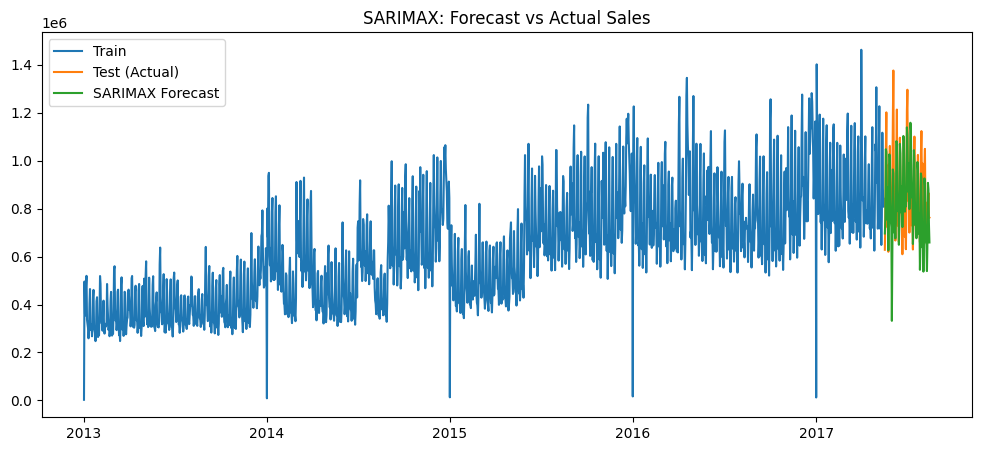

SARIMAX MAE: 99099.05411720517 RMSE: 130669.66245779795


In [ ]:
sarimax_forecast = sarimax_res.predict(
    start=len(y_train),
    end=len(y_train)+len(y_test)-1,
    exog=exog_test
)

plt.figure(figsize=(12, 5))
plt.plot(train.index, y_train, label="Train")
plt.plot(test.index, y_test, label="Test (Actual)")
plt.plot(test.index, sarimax_forecast, label="SARIMAX Forecast")
plt.legend()
plt.title("SARIMAX: Forecast vs Actual Sales")
plt.show()

mae_sarimax = mean_absolute_error(y_test, sarimax_forecast)
rmse_sarimax = sqrt(mean_squared_error(y_test, sarimax_forecast))
print("SARIMAX MAE:", mae_sarimax, "RMSE:", rmse_sarimax)


In [ ]:
prophet_train = train.reset_index()[["date", "sales", "promo_intensity"]]
prophet_train.columns = ["ds", "y", "promo_intensity"]

prophet_test = test.reset_index()[["date", "sales", "promo_intensity"]]
prophet_test.columns = ["ds", "y", "promo_intensity"]

m = Prophet(yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False)
m.add_regressor("promo_intensity")

m = m.fit(prophet_train)
print("Prophet fitted.")


Prophet fitted.


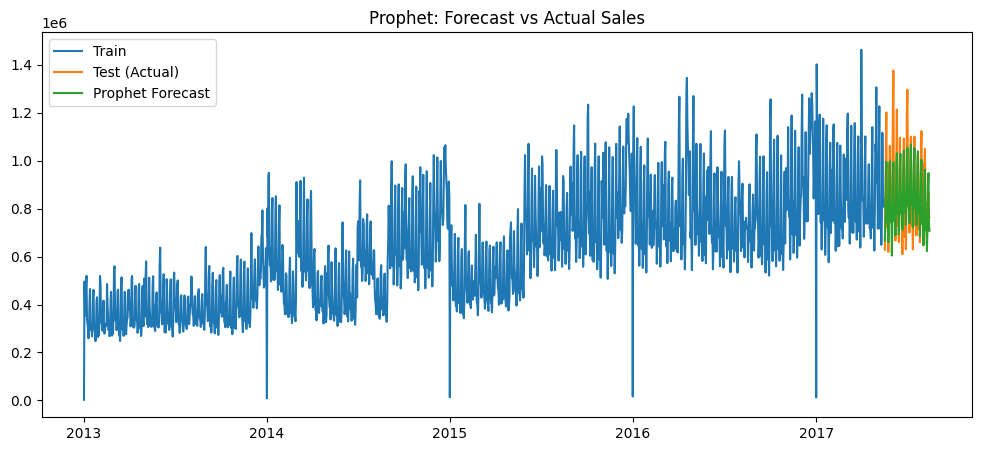

Prophet MAE: 74913.88370590168 RMSE: 100558.8689949519


In [ ]:
future = pd.concat([prophet_train[["ds", "promo_intensity"]],
                    prophet_test[["ds", "promo_intensity"]]], ignore_index=True)

forecast = m.predict(future)
prophet_forecast = forecast.iloc[-len(test):]["yhat"].values

plt.figure(figsize=(12, 5))
plt.plot(train.index, y_train, label="Train")
plt.plot(test.index, y_test, label="Test (Actual)")
plt.plot(test.index, prophet_forecast, label="Prophet Forecast")
plt.legend()
plt.title("Prophet: Forecast vs Actual Sales")
plt.show()

mae_prophet = mean_absolute_error(y_test, prophet_forecast)
rmse_prophet = sqrt(mean_squared_error(y_test, prophet_forecast))
print("Prophet MAE:", mae_prophet, "RMSE:", rmse_prophet)


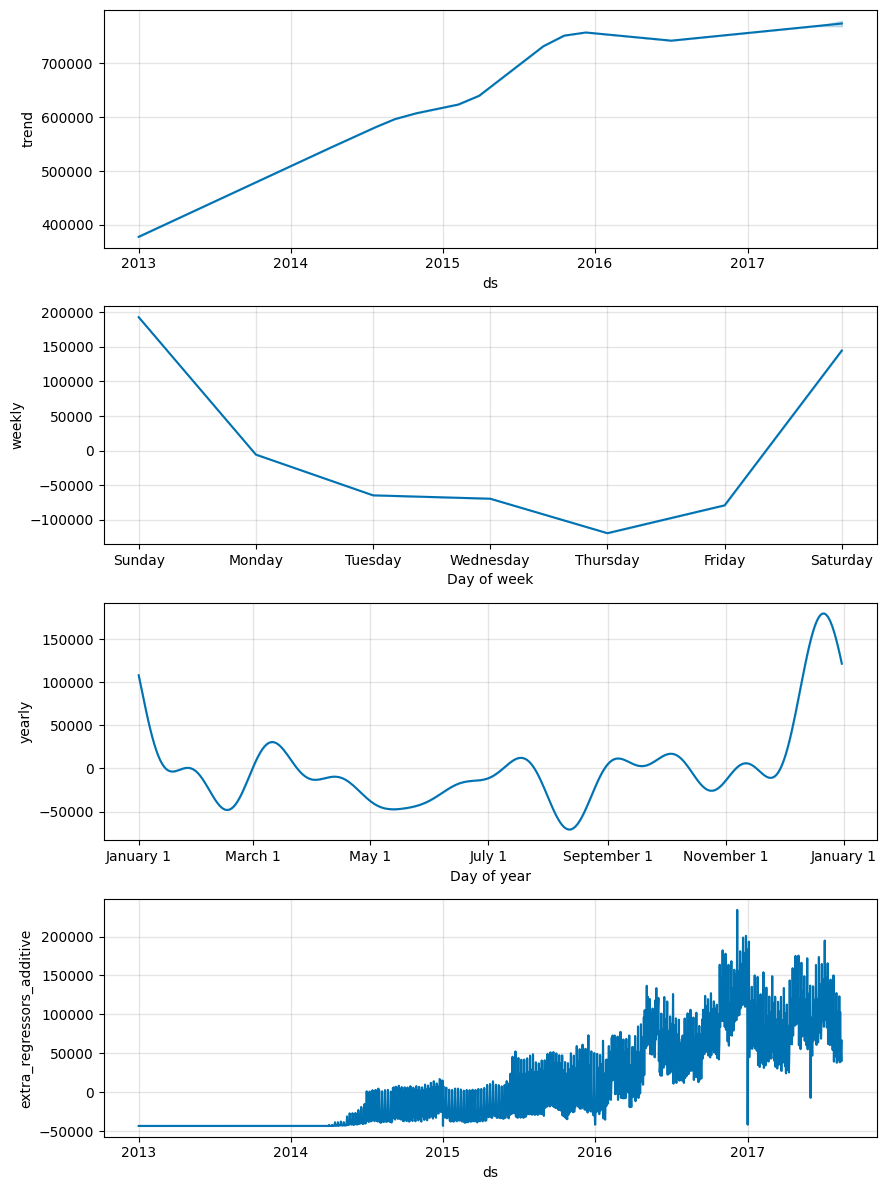

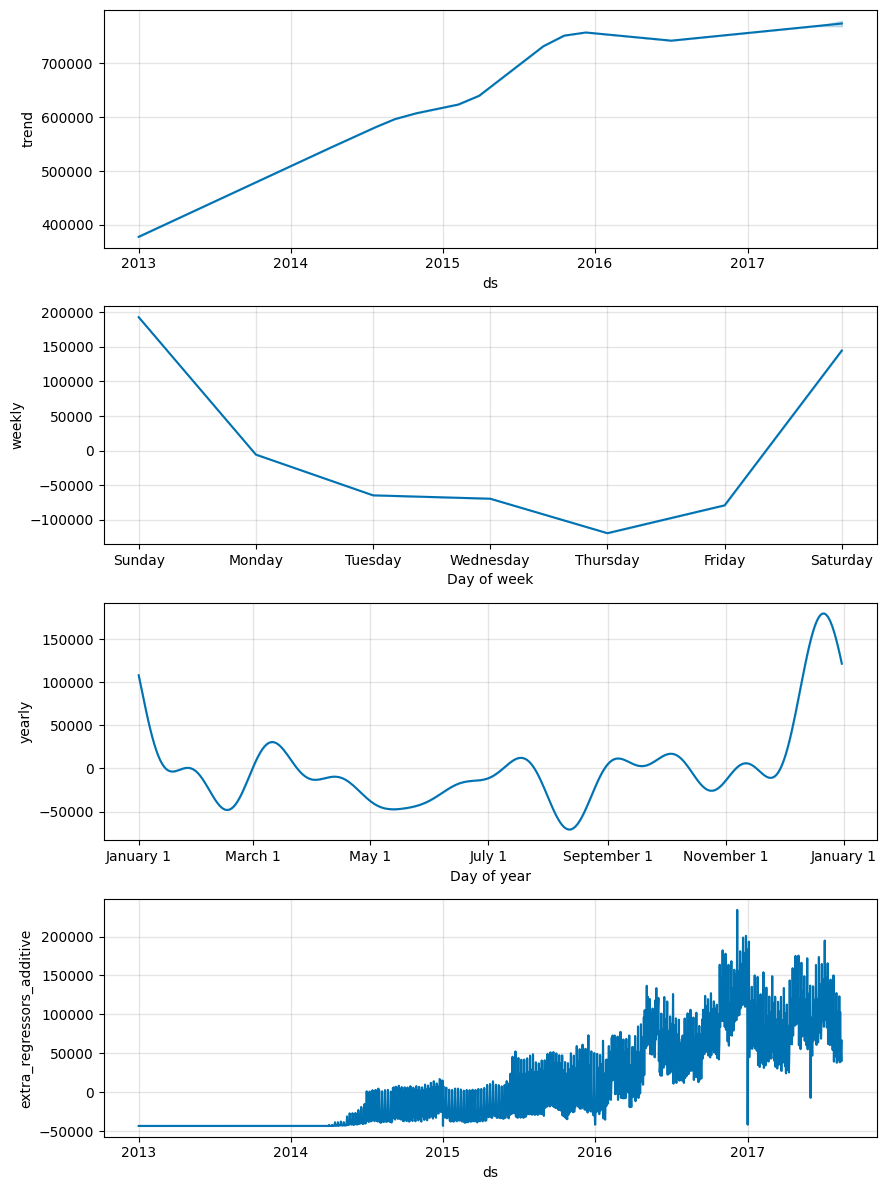

In [ ]:
m.plot_components(forecast)


In [ ]:
data_lstm = daily[["sales", "promo_intensity"]].copy()

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data_lstm)

n_steps = 30
X, y = [], []
for i in range(n_steps, len(scaled)):
    X.append(scaled[i-n_steps:i, :])
    y.append(scaled[i, 0])

X = np.array(X)
y = np.array(y)
dates_seq = daily.index[n_steps:]

split_idx = len(daily) - test_size - n_steps
X_train, X_test = X[:split_idx], X[split_idx:]
y_train_seq, y_test_seq = y[:split_idx], y[split_idx:]
dates_train_seq, dates_test_seq = dates_seq[:split_idx], dates_seq[split_idx:]


In [ ]:
model = Sequential()
model.add(LSTM(64, input_shape=(n_steps, X.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(loss="mse", optimizer="adam")
model.summary()

history = model.fit(
    X_train, y_train_seq,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,217 (67.25 KB)

 Trainable params: 17,217 (67.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0772 - val_loss: 0.0183
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0119 - val_loss: 0.0175
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0118 - val_loss: 0.0175
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0113 - val_loss: 0.0176
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0114 - val_loss: 0.0180
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0122 - val_loss: 0.0180
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0115 - val_loss: 0.0175
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0116 - val_loss: 0.0176
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0107 - val_loss: 0.0174
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0103 - val_loss: 0.0200
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0119 - val_loss: 0.0173
Epoch 12/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


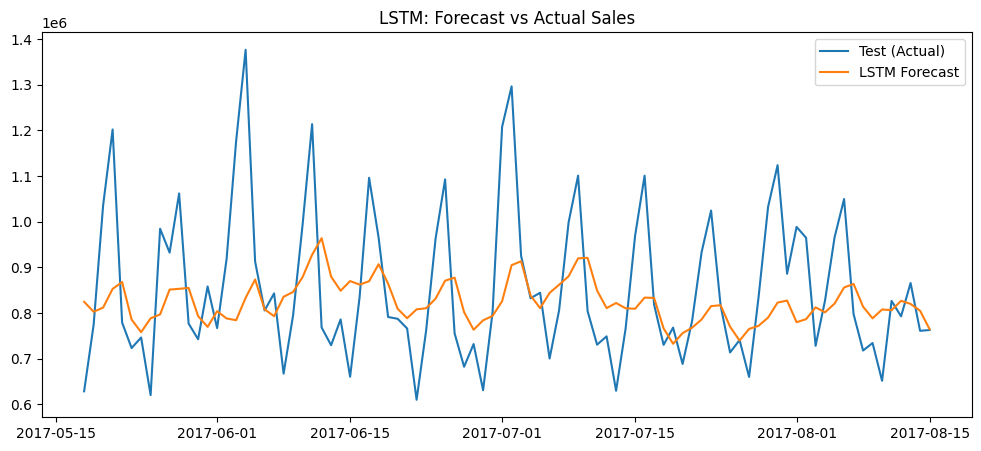

LSTM MAE: 119068.34318656515 RMSE: 158261.03306506237


In [ ]:
y_pred_scaled = model.predict(X_test)

inv_pred = np.zeros((len(y_pred_scaled), data_lstm.shape[1]))
inv_pred[:, 0] = y_pred_scaled[:, 0]

inv_true = np.zeros((len(y_test_seq), data_lstm.shape[1]))
inv_true[:, 0] = y_test_seq

y_pred_inv = scaler.inverse_transform(inv_pred)[:, 0]
y_true_inv = scaler.inverse_transform(inv_true)[:, 0]

y_pred_final = y_pred_inv[-test_size:]
y_true_final = y_true_inv[-test_size:]
dates_final = dates_test_seq[-test_size:]

plt.figure(figsize=(12, 5))
plt.plot(test.index, y_test, label="Test (Actual)")
plt.plot(dates_final, y_pred_final, label="LSTM Forecast")
plt.legend()
plt.title("LSTM: Forecast vs Actual Sales")
plt.show()

mae_lstm = mean_absolute_error(y_true_final, y_pred_final)
rmse_lstm = sqrt(mean_squared_error(y_true_final, y_pred_final))
print("LSTM MAE:", mae_lstm, "RMSE:", rmse_lstm)


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["SARIMAX", "Prophet", "LSTM"],
    "MAE": [mae_sarimax, mae_prophet, mae_lstm],
    "RMSE": [rmse_sarimax, rmse_prophet, rmse_lstm]
})
print(results)


     Model            MAE           RMSE
0  SARIMAX   99099.054117  130669.662458
1  Prophet   74913.883706  100558.868995
2     LSTM  119068.343187  158261.033065
